# Walk to Mordor — ETL Notebook

This notebook builds the data foundation for the **Walk to Mordor** portfolio
project: three virtual walking challenges through Middle-earth completed via
[The Conqueror](https://www.theconqueror.events/), powered by personal Google
Fit data.

**What this notebook does**

1. Loads and inspects the raw Google Fit export.
2. Audits the aggregate daily file against individual 15-minute interval files.
3. Selects a canonical data source and minimises it to `date / steps /
   distance_miles`.
4. Runs data-quality checks.
5. Combines the Google Fit data with the three Conqueror challenge journeys.
6. Investigates every segment boundary explicitly — distinguishing intentional
   pauses, inter-journey gaps, and possible missed-logging days.
7. Produces two small, public-safe output files in `data/processed/`.

**What this notebook does NOT do**

- Build any visualisation or website.
- Choose fictional map coordinates.
- Silently fill gaps or manufacture zero-mile days.
- Touch anything inside `raw_data/`.

At the end, a validation summary is produced. **Stop here and review boundary
decisions before moving to the visualisation phase.**


## 1. Setup

Import standard libraries and locate the repository root. The path detection
works whether Jupyter sets `cwd` to the repo root or to `notebooks/`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 60)

# ── Locate repo root ──────────────────────────────────────────────────────
_cwd = Path.cwd()
if (_cwd / "raw_data").exists():
    REPO_ROOT = _cwd
elif (_cwd.parent / "raw_data").exists():
    REPO_ROOT = _cwd.parent
else:
    raise RuntimeError(f"Cannot find repo root from {_cwd}")

FIT_DIR = REPO_ROOT / "raw_data" / "Fit" / "Daily activity metrics"
AGG_FILE = FIT_DIR / "Daily activity metrics.csv"
OUTPUT_DIR = REPO_ROOT / "data" / "processed"

# print(f"Repo root  : {REPO_ROOT}")
# print(f"Fit dir    : {FIT_DIR}")
# print(f"Aggregate  : {AGG_FILE.name}  (exists: {AGG_FILE.exists()})")
# print(f"Output dir : {OUTPUT_DIR}")

## 2. Load and Inspect the Google Fit Aggregate

Load `Daily activity metrics.csv` and inspect it thoroughly before relying
on it. We check shape, column names, dtypes, date range, missing values, and
duplicate dates.


In [2]:
agg_raw = pd.read_csv(AGG_FILE, parse_dates=["Date"])
print(f"Shape : {agg_raw.shape}")
print(f"\nColumns:")
for c in agg_raw.columns:
    print(f"  {c!r}")

Shape : (1743, 19)

Columns:
  'Date'
  'Move Minutes count'
  'Calories (kcal)'
  'Distance (m)'
  'Heart Points'
  'Heart Minutes'
  'Average speed (m/s)'
  'Max speed (m/s)'
  'Min speed (m/s)'
  'Step count'
  'Average weight (kg)'
  'Max weight (kg)'
  'Min weight (kg)'
  'Biking duration (ms)'
  'Walking duration (ms)'
  'Running duration (ms)'
  'Strength training duration (ms)'
  'Weight lifting duration (ms)'
  'Other duration (ms)'


In [3]:
print("Dtypes:")
print(agg_raw.dtypes.to_string())

Dtypes:
Date                               datetime64[us]
Move Minutes count                        float64
Calories (kcal)                           float64
Distance (m)                              float64
Heart Points                              float64
Heart Minutes                             float64
Average speed (m/s)                       float64
Max speed (m/s)                           float64
Min speed (m/s)                           float64
Step count                                  int64
Average weight (kg)                       float64
Max weight (kg)                           float64
Min weight (kg)                           float64
Biking duration (ms)                      float64
Walking duration (ms)                     float64
Running duration (ms)                     float64
Strength training duration (ms)           float64
Weight lifting duration (ms)              float64
Other duration (ms)                       float64


In [4]:
print(
    f"Date range       : {agg_raw['Date'].min().date()} → {agg_raw['Date'].max().date()}"
)
print(f"Total rows       : {len(agg_raw):,}")

dup = agg_raw["Date"].duplicated()
print(f"Duplicate dates  : {dup.sum()}")
if dup.sum():
    display(agg_raw[dup][["Date"]])

print(f"\nMissing values per column:")
print(agg_raw.isnull().sum().to_string())

Date range       : 2021-12-03 → 2026-09-10
Total rows       : 1,743
Duplicate dates  : 0

Missing values per column:
Date                                  0
Move Minutes count                    5
Calories (kcal)                       0
Distance (m)                          2
Heart Points                         69
Heart Minutes                        69
Average speed (m/s)                  74
Max speed (m/s)                      74
Min speed (m/s)                      74
Step count                            0
Average weight (kg)                1733
Max weight (kg)                    1733
Min weight (kg)                    1733
Biking duration (ms)                940
Walking duration (ms)                 6
Running duration (ms)              1463
Strength training duration (ms)    1612
Weight lifting duration (ms)       1726
Other duration (ms)                1740


In [5]:
# Descriptive stats for the two fields we will keep
agg_raw[["Step count", "Distance (m)"]].describe()

,Step count,Distance (m)
count,1743.000000,1741.000000
mean,13459.433161,8469.625709
std,7512.136624,5005.410120
min,12.000000,4.927451
25%,7704.000000,4771.797141
50%,13040.000000,7803.659241
75%,18230.000000,11428.909945
max,41965.000000,28026.308013


## 3. Inspect Individual Daily Files

Each `YYYY-MM-DD.csv` records 15-minute activity intervals for one day.
We compare the summed totals from those files against the corresponding rows
in the aggregate to determine whether the aggregate is a reliable canonical
source.


In [6]:
# Examine the structure of one individual file
sample_file = FIT_DIR / "2024-03-27.csv"
sample_daily = pd.read_csv(sample_file)
print(f"Shape   : {sample_daily.shape}")
print(f"Columns : {sample_daily.columns.tolist()}")
# sample_daily.head(6)

Shape   : (96, 16)
Columns : ['Start time', 'End time', 'Move Minutes count', 'Calories (kcal)', 'Distance (m)', 'Heart Points', 'Heart Minutes', 'Average speed (m/s)', 'Max speed (m/s)', 'Min speed (m/s)', 'Step count', 'Average weight (kg)', 'Max weight (kg)', 'Min weight (kg)', 'Walking duration (ms)', 'Running duration (ms)']


In [7]:
# Spot-check 8 dates spread across the full project timeline
spot_dates = [
    "2024-03-27",
    "2024-05-15",
    "2024-07-20",
    "2024-10-01",
    "2024-12-15",
    "2025-02-10",
    "2025-06-15",
    "2026-04-15",
]

rows = []
for ds in spot_dates:
    daily_path = FIT_DIR / f"{ds}.csv"
    if not daily_path.exists():
        rows.append({"date": ds, "note": "daily file missing"})
        continue
    daily = pd.read_csv(daily_path)
    ind_steps = daily["Step count"].sum()
    ind_dist = daily["Distance (m)"].sum()

    agg_row = agg_raw[agg_raw["Date"] == pd.Timestamp(ds)]
    if agg_row.empty:
        rows.append({"date": ds, "note": "date absent from aggregate"})
        continue

    agg_steps = agg_row["Step count"].values[0]
    agg_dist = agg_row["Distance (m)"].values[0]
    rows.append(
        {
            "date": ds,
            "ind_steps": int(ind_steps) if pd.notna(ind_steps) else None,
            "agg_steps": int(agg_steps) if pd.notna(agg_steps) else None,
            "steps_delta": (
                abs(ind_steps - agg_steps)
                if (pd.notna(ind_steps) and pd.notna(agg_steps))
                else None
            ),
            "ind_dist_m": round(float(ind_dist), 1) if pd.notna(ind_dist) else None,
            "agg_dist_m": round(float(agg_dist), 1) if pd.notna(agg_dist) else None,
            "dist_delta_m": (
                round(abs(float(ind_dist) - float(agg_dist)), 1)
                if (pd.notna(ind_dist) and pd.notna(agg_dist))
                else None
            ),
        }
    )

spot_check = pd.DataFrame(rows)
# spot_check

In [8]:
# Programmatic audit across ~50 evenly-spaced dates
daily_files = sorted(FIT_DIR.glob("[0-9][0-9][0-9][0-9]-[0-9][0-9]-[0-9][0-9].csv"))
step_size = max(1, len(daily_files) // 50)
sampled = daily_files[::step_size][:50]

step_diffs, dist_diffs = [], []
for f in sampled:
    ds = f.stem
    agg_row = agg_raw[agg_raw["Date"] == pd.Timestamp(ds)]
    if agg_row.empty:
        continue
    daily = pd.read_csv(f)
    ind_steps = daily["Step count"].sum()
    ind_dist = daily["Distance (m)"].sum()
    agg_steps = agg_row["Step count"].values[0]
    agg_dist = agg_row["Distance (m)"].values[0]
    if pd.notna(ind_steps) and pd.notna(agg_steps):
        step_diffs.append(abs(ind_steps - agg_steps))
    if pd.notna(ind_dist) and pd.notna(agg_dist):
        dist_diffs.append(abs(ind_dist - agg_dist))

n = len(sampled)
print(f"Files sampled   : {n}")
if step_diffs:
    print(f"\nStep count deltas (n={len(step_diffs)}):")
    print(f"  Mean absolute : {np.mean(step_diffs):.2f}")
    print(f"  Max absolute  : {np.max(step_diffs):.2f}")
    print(f"  Exact matches : {sum(d == 0 for d in step_diffs)}/{len(step_diffs)}")
if dist_diffs:
    print(f"\nDistance (m) deltas (n={len(dist_diffs)}):")
    print(f"  Mean absolute : {np.mean(dist_diffs):.3f} m")
    print(f"  Max absolute  : {np.max(dist_diffs):.3f} m")
    print(
        f"  Near-zero (<0.01 m) : {sum(d < 0.01 for d in dist_diffs)}/{len(dist_diffs)}"
    )

Files sampled   : 50

Step count deltas (n=50):
  Mean absolute : 0.12
  Max absolute  : 3.00
  Exact matches : 46/50

Distance (m) deltas (n=49):
  Mean absolute : 0.000 m
  Max absolute  : 0.000 m
  Near-zero (<0.01 m) : 49/49


## 4. Establish the Canonical Google Fit Source

Based on the comparison above:

- **Option A** — Use `Daily activity metrics.csv` as-is *(preferred if reliable)*
- **Option B** — Reconstruct daily totals from the individual 15-minute files


In [9]:
max_step_diff = max(step_diffs) if step_diffs else float("inf")
max_dist_diff = max(dist_diffs) if dist_diffs else float("inf")

if max_step_diff <= 5 and max_dist_diff <= 1.0:
    decision = "Option A — Use Daily activity metrics.csv"
    rationale = (
        f"Aggregate matches individual file totals within rounding tolerance "
        f"(max step delta = {max_step_diff:.0f}, max dist delta = {max_dist_diff:.2f} m). "
        f"The aggregate is a reliable canonical source."
    )
else:
    decision = "Option B — Reconstruct from individual files"
    rationale = (
        f"Meaningful discrepancies detected "
        f"(max step delta = {max_step_diff:.0f}, max dist delta = {max_dist_diff:.2f} m). "
        f"Recommend reconstructing daily totals from individual 15-minute files."
    )

print(f"Decision  : {decision}")
print(f"Rationale : {rationale}")

Decision  : Option A — Use Daily activity metrics.csv
Rationale : Aggregate matches individual file totals within rounding tolerance (max step delta = 3, max dist delta = 0.00 m). The aggregate is a reliable canonical source.


## 5. Minimize the Google Fit Data

Retain only `date`, `steps`, and `distance_miles`.

Convert `Distance (m)` → miles (1 mile = 1,609.344 m).

**Dropped columns:** calories, weight, heart points, heart minutes, speeds,
activity durations, and all other health metrics. None of these enter the
processed public dataset.


In [10]:
METRES_PER_MILE = 1609.344

fit = (
    agg_raw[["Date", "Step count", "Distance (m)"]]
    .copy()
    .rename(
        columns={
            "Date": "date",
            "Step count": "steps",
            "Distance (m)": "distance_m",
        }
    )
)
fit["distance_miles"] = fit["distance_m"] / METRES_PER_MILE
fit = fit.drop(columns=["distance_m"])
fit = fit.sort_values("date").reset_index(drop=True)

print(f"Shape   : {fit.shape}")
print(f"Columns : {fit.columns.tolist()}")
fit.head(10)

Shape   : (1743, 3)
Columns : ['date', 'steps', 'distance_miles']


,date,steps,distance_miles
0,2021-12-03,11923,4.788907
1,2021-12-04,21962,8.139389
2,2021-12-05,15904,5.567444
3,2021-12-06,10965,3.718478
4,2021-12-07,14593,5.980636
5,2021-12-08,8212,3.140672
6,2021-12-09,11366,4.033821
7,2021-12-10,17435,6.169482
8,2021-12-11,15728,5.336940
9,2021-12-12,15385,5.304638


## 6. Data-Quality Audit

Systematic checks for date integrity, step validity, distance validity, and
internal plausibility (distance per step).


In [11]:
print("── DATE AUDIT ──────────────────────────────────────────────────")
print(
    f"  Date range             : {fit['date'].min().date()} → {fit['date'].max().date()}"
)
print(f"  Total rows             : {len(fit):,}")
print(f"  Duplicate dates        : {fit['date'].duplicated().sum()}")
print(f"  Chronologically sorted : {fit['date'].is_monotonic_increasing}")

full_range = pd.date_range(fit["date"].min(), fit["date"].max(), freq="D")
missing_dates = full_range.difference(fit["date"])
print(f"  Missing calendar dates : {len(missing_dates)}")
if 0 < len(missing_dates) <= 20:
    print("  Missing:", [d.date().isoformat() for d in missing_dates])
elif len(missing_dates) > 20:
    print(f"  First 5 missing: {[d.date().isoformat() for d in missing_dates[:5]]}")

── DATE AUDIT ──────────────────────────────────────────────────
  Date range             : 2021-12-03 → 2026-09-10
  Total rows             : 1,743
  Duplicate dates        : 0
  Chronologically sorted : True
  Missing calendar dates : 0


In [12]:
print("── STEPS AUDIT ─────────────────────────────────────────────────")
print(f"  Null values      : {fit['steps'].isnull().sum()}")
print(f"  Zero values      : {(fit['steps'] == 0).sum()}")
print(f"  Negative values  : {(fit['steps'] < 0).sum()}")
print(f"  > 100,000 steps  : {(fit['steps'] > 100_000).sum()}")
print()
print(fit["steps"].describe().round(0).to_string())

── STEPS AUDIT ─────────────────────────────────────────────────
  Null values      : 0
  Zero values      : 0
  Negative values  : 0
  > 100,000 steps  : 0

count     1743.0
mean     13459.0
std       7512.0
min         12.0
25%       7704.0
50%      13040.0
75%      18230.0
max      41965.0


In [13]:
print("── DISTANCE AUDIT ──────────────────────────────────────────────")
print(f"  Null values         : {fit['distance_miles'].isnull().sum()}")
print(f"  Zero values         : {(fit['distance_miles'] == 0).sum()}")
print(f"  Negative values     : {(fit['distance_miles'] < 0).sum()}")
print(f"  > 50 miles in a day : {(fit['distance_miles'] > 50).sum()}")
if (fit["distance_miles"] > 50).sum():
    display(fit[fit["distance_miles"] > 50][["date", "steps", "distance_miles"]])
print()
print(fit["distance_miles"].describe().round(4).to_string())

── DISTANCE AUDIT ──────────────────────────────────────────────
  Null values         : 2
  Zero values         : 0
  Negative values     : 0
  > 50 miles in a day : 0

count    1741.0000
mean        5.2628
std         3.1102
min         0.0031
25%         2.9651
50%         4.8490
75%         7.1016
max        17.4147


In [14]:
print("── PLAUSIBILITY: distance per step ─────────────────────────────")
# Flag rows where implied step length is outside a plausible range
# Typical step ≈ 0.76 m ≈ 0.000472 miles
LOW_MI_PER_STEP = 0.0001  # < ~16 cm per step
HIGH_MI_PER_STEP = 0.0010  # > ~161 cm per step

active = fit[(fit["steps"] > 0) & fit["distance_miles"].notna()].copy()
active["mi_per_step"] = active["distance_miles"] / active["steps"]
print(f"  Active rows (steps > 0, dist not null): {len(active):,}")
print()
print(active["mi_per_step"].describe().to_string())

outliers = active[
    (active["mi_per_step"] < LOW_MI_PER_STEP)
    | (active["mi_per_step"] > HIGH_MI_PER_STEP)
]
print(
    f"\n  Outliers (outside [{LOW_MI_PER_STEP}, {HIGH_MI_PER_STEP}] mi/step): {len(outliers)}"
)
if len(outliers):
    display(outliers[["date", "steps", "distance_miles", "mi_per_step"]].head(20))

── PLAUSIBILITY: distance per step ─────────────────────────────
  Active rows (steps > 0, dist not null): 1,741

count    1741.000000
mean        0.000382
std         0.000036
min         0.000047
25%         0.000362
50%         0.000388
75%         0.000409
max         0.000482

  Outliers (outside [0.0001, 0.001] mi/step): 2


,date,steps,distance_miles,mi_per_step
790,2024-02-01,65,0.003062,0.000047
1460,2025-12-02,80,0.003827,0.000048


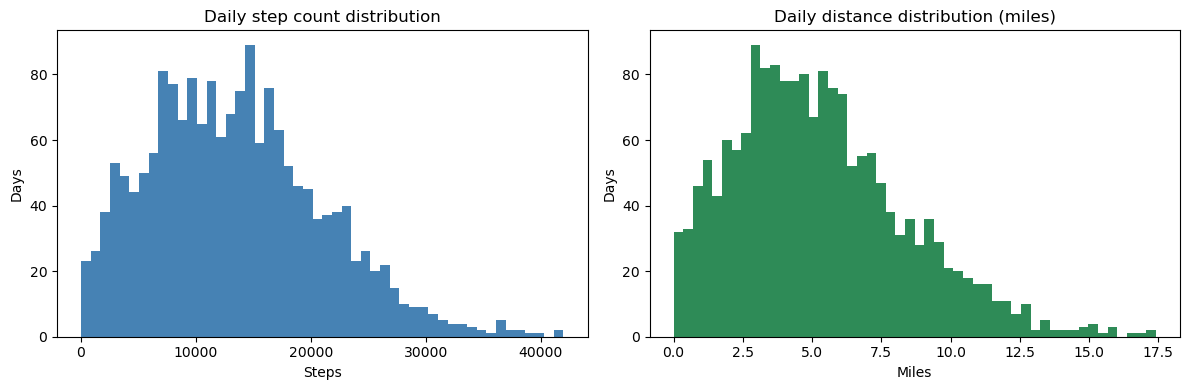

In [15]:
# Optional: histogram of daily step counts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fit["steps"].dropna(), bins=50, edgecolor="none", color="steelblue")
axes[0].set_title("Daily step count distribution")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Days")

axes[1].hist(
    fit["distance_miles"].dropna(), bins=50, edgecolor="none", color="seagreen"
)
axes[1].set_title("Daily distance distribution (miles)")
axes[1].set_xlabel("Miles")
axes[1].set_ylabel("Days")

plt.tight_layout()
plt.show()

## 7. Conqueror Journey Data

Load the Conqueror challenge metadata from `conqueror.csv`.

Dates are in `DD-MM-YY` format. Cumulative mileage within each journey is
computed from the `target_miles` column. These values describe the **fictional
challenge route**, not actual walking distance.

**Note:** Some consecutive segments within a journey share a boundary date
(e.g., "The Fellowship" ends and "Mines of Moria" starts on the same day —
both 24-Jul-2024). On such shared days the notebook attributes the date to
the incoming segment (the one that starts on that day). This is flagged below.


In [16]:
conqueror = pd.read_csv(REPO_ROOT / "data" / "conqueror.csv")
conqueror["start_date"] = pd.to_datetime(conqueror["start_date"], format="%d-%m-%y")
conqueror["end_date"] = pd.to_datetime(conqueror["end_date"], format="%d-%m-%y")

# Sort within each journey by start_date so cumulative sums are correct
conqueror = conqueror.sort_values(["journey_id", "start_date"]).reset_index(drop=True)
conqueror["cum_miles_end"] = conqueror.groupby("journey_id")["target_miles"].cumsum()
conqueror["cum_miles_start"] = conqueror["cum_miles_end"] - conqueror["target_miles"]

# Re-sort globally by start_date for display and boundary analysis
conqueror = conqueror.sort_values("start_date").reset_index(drop=True)

display(
    conqueror[
        [
            "journey_id",
            "name",
            "character",
            "start_date",
            "end_date",
            "target_miles",
            "cum_miles_start",
            "cum_miles_end",
            "number_of_distances_logged",
        ]
    ]
)

,journey_id,name,character,start_date,end_date,target_miles,cum_miles_start,cum_miles_end,number_of_distances_logged
0,Mordor,The Shire,Frodo,2024-03-27,2024-04-28,145,0,145,29
1,Mordor,The Fellowship,Frodo,2024-04-29,2024-07-24,680,145,825,87
2,Mordor,Mines of Moria,Frodo,2024-07-24,2024-07-28,40,825,865,5
3,Mordor,The Eye of Sauron,Frodo,2024-08-24,2024-12-04,668,865,1533,99
4,Mordor,Mordor,Frodo,2024-12-04,2025-01-07,282,1533,1815,35
5,Return,Rohan,Aragorn,2025-01-14,2025-03-29,450,0,450,75
6,Return,Helm's Deep,Aragorn,2025-03-30,2025-06-04,370,450,820,64
7,Return,Gondor,Aragorn,2025-06-05,2025-08-26,662,820,1482,85
8,Hobbit,An Unexpected Journey,Bilbo,2026-01-20,2026-04-07,609,0,609,78
9,Hobbit,The Desolation of Smaug,Bilbo,2026-04-08,2026-05-31,416,609,1025,55


In [17]:
print("Journey totals (Conqueror target miles):")
totals = (
    conqueror.groupby(["journey_id", "character"])["target_miles"]
    .sum()
    .reset_index()
    .rename(columns={"target_miles": "total_target_miles"})
)
display(totals)

Journey totals (Conqueror target miles):


,journey_id,character,total_target_miles
0,Hobbit,Bilbo,1100
1,Mordor,Frodo,1815
2,Return,Aragorn,1482


In [18]:
# Flag any same-day overlaps between consecutive segments
same_day_overlaps = []
for i in range(len(conqueror) - 1):
    a = conqueror.iloc[i]
    b = conqueror.iloc[i + 1]
    if a["journey_id"] == b["journey_id"] and a["end_date"] == b["start_date"]:
        same_day_overlaps.append(
            {
                "shared_date": a["end_date"].date(),
                "outgoing": a["name"],
                "incoming": b["name"],
                "assigned_to": b["name"],  # later-starting segment wins
            }
        )

if same_day_overlaps:
    print("Same-day boundary overlaps (attributed to the incoming/starting segment):")
    display(pd.DataFrame(same_day_overlaps))
else:
    print("No same-day boundary overlaps found.")

Same-day boundary overlaps (attributed to the incoming/starting segment):


,shared_date,outgoing,incoming,assigned_to
0,2024-07-24,The Fellowship,Mines of Moria,Mines of Moria
1,2024-12-04,The Eye of Sauron,Mordor,Mordor


## 8. Assign Google Fit Dates to Journeys

For each date in `fit`, determine which Conqueror segment was active.

**Rules encoded here:**

| Situation | Treatment |
|---|---|
| Date falls inside a segment's `[start_date, end_date]` | Assigned to that segment |
| Frodo pause Jul 29 – Aug 23, 2024 | `NaN` — intentional break, not assigned |
| Inter-journey gaps (Frodo→Aragorn Jan 8–13; Aragorn→Bilbo Sep–Jan) | `NaN` — separate journeys |
| Same-day boundary between two consecutive segments | Attributed to the incoming segment |
| Any other gap day (e.g., 1-day logging gap inside a journey) | `NaN` — flagged in Section 9 |

Nothing is silently filled or classified. Gaps are preserved as `NaN`.


In [19]:
def find_segment(date, segs):
    """
    Return (journey_id, character, segment_name) for the active segment on
    `date`, or (pd.NA, pd.NA, pd.NA) if no segment covers that date.

    When two segments share a boundary date, the one with the later start_date
    (the 'incoming' segment) takes precedence.
    """
    matches = segs[
        (segs["start_date"] <= date) & (segs["end_date"] >= date)
    ].sort_values(
        "start_date", ascending=False
    )  # latest start wins
    if matches.empty:
        return pd.NA, pd.NA, pd.NA
    row = matches.iloc[0]
    return row["journey_id"], row["character"], row["name"]


results = fit["date"].apply(lambda d: find_segment(d, conqueror))
fit_with_journey = fit.copy()
fit_with_journey[["journey_id", "character", "segment"]] = pd.DataFrame(
    results.tolist(), index=fit.index
)

assigned = fit_with_journey["journey_id"].notna().sum()
unassigned = fit_with_journey["journey_id"].isna().sum()
print(f"Assigned to a segment        : {assigned:,} days")
print(f"Unassigned (gap/out-of-range): {unassigned:,} days")
print()
print("Days assigned per segment:")
print(
    fit_with_journey.groupby(["journey_id", "character", "segment"])
    .size()
    .rename("days_assigned")
    .to_string()
)

Assigned to a segment        : 628 days
Unassigned (gap/out-of-range): 1,115 days

Days assigned per segment:
journey_id  character  segment                      
Hobbit      Bilbo      An Unexpected Journey             78
                       The Battle of the Five Armies     10
                       The Desolation of Smaug           54
Mordor      Frodo      Mines of Moria                     5
                       Mordor                            35
                       The Eye of Sauron                102
                       The Fellowship                    86
                       The Shire                         33
Return      Aragorn    Gondor                            83
                       Helm's Deep                       67
                       Rohan                             75


## 9. Investigate Boundary Ambiguity

For every consecutive pair of segments, this table shows:

- the calendar gap between them
- how many Google Fit *active* days fall inside that gap
- total steps and miles recorded by Google Fit during the gap

This lets us distinguish:

| Pattern | Interpretation |
|---|---|
| ≥ 20 days, same journey | **Intentional challenge pause** |
| Different `journey_id` | **Inter-journey boundary** |
| 1–2 days, some walking | **Missed Conqueror logging** — review |
| 1 day, no walking | Transition day — no action needed |

Ambiguous cases are flagged. **Do not resolve them without reviewing this table.**


In [20]:
boundary_rows = []
for i in range(len(conqueror) - 1):
    seg_a = conqueror.iloc[i]
    seg_b = conqueror.iloc[i + 1]

    gap_start = seg_a["end_date"] + pd.Timedelta(days=1)
    gap_end = seg_b["start_date"] - pd.Timedelta(days=1)
    calendar_gap = int((seg_b["start_date"] - seg_a["end_date"]).days)
    same_journey = seg_a["journey_id"] == seg_b["journey_id"]

    if calendar_gap > 0:
        gap_fit = fit[(fit["date"] >= gap_start) & (fit["date"] <= gap_end)]
        active_gap_days = int((gap_fit["steps"].fillna(0) > 0).sum())
        gap_total_steps = int(gap_fit["steps"].fillna(0).sum())
        gap_total_miles = round(float(gap_fit["distance_miles"].fillna(0).sum()), 2)
    else:
        active_gap_days = gap_total_steps = 0
        gap_total_miles = 0.0

    # Automated classification (user should review)
    if not same_journey:
        note = "inter-journey boundary"
    elif calendar_gap >= 20:
        note = "intentional challenge pause"
    elif calendar_gap == 0:
        note = "same-day boundary — attributed to incoming segment"
    elif calendar_gap <= 2 and active_gap_days > 0:
        note = (
            f"⚠ SHORT GAP ({calendar_gap}d), {active_gap_days} active day(s) — review"
        )
    elif calendar_gap <= 2 and active_gap_days == 0:
        note = "short gap, no walking recorded"
    else:
        note = f"{calendar_gap}-day gap"

    boundary_rows.append(
        {
            "prev_segment": seg_a["name"],
            "prev_journey": seg_a["journey_id"],
            "prev_end": seg_a["end_date"].date(),
            "next_segment": seg_b["name"],
            "next_journey": seg_b["journey_id"],
            "next_start": seg_b["start_date"].date(),
            "same_journey": same_journey,
            "calendar_gap_days": calendar_gap,
            "active_gap_days": active_gap_days,
            "gap_total_steps": gap_total_steps,
            "gap_total_miles": gap_total_miles,
            "note": note,
        }
    )

boundaries = pd.DataFrame(boundary_rows)
display(boundaries)

,prev_segment,prev_journey,prev_end,next_segment,next_journey,next_start,same_journey,calendar_gap_days,active_gap_days,gap_total_steps,gap_total_miles,note
0,The Shire,Mordor,2024-04-28,The Fellowship,Mordor,2024-04-29,True,1,0,0,0.00,"short gap, no walking recorded"
1,The Fellowship,Mordor,2024-07-24,Mines of Moria,Mordor,2024-07-24,True,0,0,0,0.00,same-day boundary — attributed to incoming segment
2,Mines of Moria,Mordor,2024-07-28,The Eye of Sauron,Mordor,2024-08-24,True,27,26,195195,72.31,intentional challenge pause
3,The Eye of Sauron,Mordor,2024-12-04,Mordor,Mordor,2024-12-04,True,0,0,0,0.00,same-day boundary — attributed to incoming segment
4,Mordor,Mordor,2025-01-07,Rohan,Return,2025-01-14,False,7,6,72569,29.11,inter-journey boundary
5,Rohan,Return,2025-03-29,Helm's Deep,Return,2025-03-30,True,1,0,0,0.00,"short gap, no walking recorded"
6,Helm's Deep,Return,2025-06-04,Gondor,Return,2025-06-05,True,1,0,0,0.00,"short gap, no walking recorded"
7,Gondor,Return,2025-08-26,An Unexpected Journey,Hobbit,2026-01-20,False,147,146,1643394,630.35,inter-journey boundary
8,An Unexpected Journey,Hobbit,2026-04-07,The Desolation of Smaug,Hobbit,2026-04-08,True,1,0,0,0.00,"short gap, no walking recorded"
9,The Desolation of Smaug,Hobbit,2026-05-31,The Battle of the Five Armies,Hobbit,2026-06-01,True,1,0,0,0.00,"short gap, no walking recorded"


### Boundary Review Checklist

Review each row above and confirm or override the `note` classification.

Key boundaries requiring explicit decisions:

| Transition | Expected interpretation |
|---|---|
| Mines of Moria → Eye of Sauron | **Intentional pause** — 27-day break in the Frodo journey. Walking during Jul 29 – Aug 23 is NOT attributed to either segment. |
| Mordor → Rohan | **Inter-journey** — Frodo's journey ends; Aragorn's begins 7 days later. |
| Gondor → An Unexpected Journey | **Inter-journey** — Aragorn ends Aug 2025; Bilbo begins Jan 2026. |
| Any row flagged ⚠ | **Requires your decision** — was this a missed log start, or a genuine rest day? |

Record your decisions in the cell below.


In [21]:
# ── User boundary decisions ───────────────────────────────────────────────
# Inspect the boundary table above and record decisions here.
# Format:  (prev_segment, next_segment) -> "assign_to_prev" | "assign_to_next" | "leave_unassigned"
#
# Default: all gap days remain UNASSIGNED until you override them here.
# Example:
#   boundary_decisions = {
#       ("Rohan", "Helm's Deep"): "leave_unassigned",
#   }

boundary_decisions = {
    # Assigned manually by changing the source data.
    # The first day of Helm's Deep and Gondor weren't logged in the app
    # because I forgot to start the app on time,
    # so I corrected it in conqueror.csv
    # making this step unnecessary
    # ("Rohan", "Helm's Deep"): "assign_to_next",  # unnecessary due to manual correction
    # ("Helm's Deep", "Gondor"): "assign_to_next",  # unnecessary due to manual correction
}

print("Boundary decisions recorded:", len(boundary_decisions))
if boundary_decisions:
    for k, v in boundary_decisions.items():
        print(f"  {k[0]} → {k[1]} : {v}")
else:
    print("  (none yet — all gap days remain unassigned)")

Boundary decisions recorded: 0
  (none yet — all gap days remain unassigned)


## 10. Determine the Project Date Range

The processed dataset includes only dates that fall within the scope of the
three challenges — from the first challenge start to the last challenge end.
Walking data outside this window is out of scope and is excluded from the
public outputs.


In [22]:
project_start = conqueror["start_date"].min()
project_end = conqueror["end_date"].max()

print(f"Project start : {project_start.date()}  (first challenge segment begins)")
print(f"Project end   : {project_end.date()}  (last challenge segment ends)")
print(f"Calendar span : {(project_end - project_start).days + 1:,} days")

fit_project = fit_with_journey[
    (fit_with_journey["date"] >= project_start)
    & (fit_with_journey["date"] <= project_end)
].copy()

print(f"\nGoogle Fit rows in project range : {len(fit_project):,}")
print(f"  assigned to a segment          : {fit_project['journey_id'].notna().sum():,}")
print(f"  in gaps / unassigned           : {fit_project['journey_id'].isna().sum():,}")

Project start : 2024-03-27  (first challenge segment begins)
Project end   : 2026-06-10  (last challenge segment ends)
Calendar span : 806 days

Google Fit rows in project range : 806
  assigned to a segment          : 628
  in gaps / unassigned           : 178


## 11. Produce the Processed Dataset

Two small, public-safe output files:

### `data/processed/daily_steps.csv`
One row per date within the project range.
Fields: `date`, `steps`, `distance_miles`, `journey_id`, `character`, `segment`.
Journey fields are `NaN` for gap days.

### `data/processed/journeys.csv`
One row per Conqueror segment.
Fields: segment metadata and cumulative mileage (fictional challenge route).

**No raw Google Fit health fields (calories, heart rate, weight, etc.) appear
in either file.**


In [23]:
# ── daily_steps.csv ───────────────────────────────────────────────────────
daily_steps = fit_project[
    ["date", "steps", "distance_miles", "journey_id", "character", "segment"]
].copy()

# Cumulative actual walking distance and steps within each journey.
# Unassigned dates (gaps / intentional pauses) do not accrue or reset totals.
daily_steps["cumulative_miles"] = daily_steps.groupby("journey_id")[
    "distance_miles"
].cumsum()
daily_steps["cumulative_steps"] = daily_steps.groupby("journey_id")["steps"].cumsum()

# Cumulative all time actual walking distance and steps (ignores journey boundaries)
daily_steps["all_time_cumulative_miles"] = daily_steps["distance_miles"].cumsum()
daily_steps["all_time_cumulative_steps"] = daily_steps["steps"].cumsum()

daily_steps["date"] = daily_steps["date"].dt.date  # YYYY-MM-DD strings

print("daily_steps preview (first 10 rows):")
display(daily_steps.head(10))
print(f"\nShape: {daily_steps.shape}")
print(f"Columns: {daily_steps.columns.tolist()}")
print(f"Rows with journey assigned : {daily_steps['journey_id'].notna().sum():,}")
print(f"Rows with journey = NaN    : {daily_steps['journey_id'].isna().sum():,}")

daily_steps preview (first 10 rows):


,date,steps,distance_miles,journey_id,character,segment,cumulative_miles,cumulative_steps,all_time_cumulative_miles,all_time_cumulative_steps
845,2024-03-27,16822,7.157441,Mordor,Frodo,The Shire,7.157441,16822.0,7.157441,16822
846,2024-03-28,9295,3.936332,Mordor,Frodo,The Shire,11.093773,26117.0,11.093773,26117
847,2024-03-29,18741,7.722736,Mordor,Frodo,The Shire,18.816509,44858.0,18.816509,44858
848,2024-03-30,18257,6.884298,Mordor,Frodo,The Shire,25.700808,63115.0,25.700808,63115
849,2024-03-31,13554,4.643142,Mordor,Frodo,The Shire,30.343950,76669.0,30.343950,76669
850,2024-04-01,9656,3.740249,Mordor,Frodo,The Shire,34.084199,86325.0,34.084199,86325
851,2024-04-02,2493,0.977009,Mordor,Frodo,The Shire,35.061207,88818.0,35.061207,88818
852,2024-04-03,1641,0.549987,Mordor,Frodo,The Shire,35.611195,90459.0,35.611195,90459
853,2024-04-04,1021,0.252720,Mordor,Frodo,The Shire,35.863914,91480.0,35.863914,91480
854,2024-04-05,12499,5.101606,Mordor,Frodo,The Shire,40.965520,103979.0,40.965520,103979



Shape: (806, 10)
Columns: ['date', 'steps', 'distance_miles', 'journey_id', 'character', 'segment', 'cumulative_miles', 'cumulative_steps', 'all_time_cumulative_miles', 'all_time_cumulative_steps']
Rows with journey assigned : 628
Rows with journey = NaN    : 178


In [24]:
# ── journeys.csv ──────────────────────────────────────────────────────────
journeys = (
    conqueror[
        [
            "journey_id",
            "name",
            "character",
            "start_date",
            "end_date",
            "target_miles",
            "cum_miles_start",
            "cum_miles_end",
            "number_of_distances_logged",
        ]
    ]
    .copy()
    .rename(columns={"name": "segment"})
)
journeys["start_date"] = journeys["start_date"].dt.date
journeys["end_date"] = journeys["end_date"].dt.date

print("journeys.csv (all rows):")
display(journeys)

journeys.csv (all rows):


,journey_id,segment,character,start_date,end_date,target_miles,cum_miles_start,cum_miles_end,number_of_distances_logged
0,Mordor,The Shire,Frodo,2024-03-27,2024-04-28,145,0,145,29
1,Mordor,The Fellowship,Frodo,2024-04-29,2024-07-24,680,145,825,87
2,Mordor,Mines of Moria,Frodo,2024-07-24,2024-07-28,40,825,865,5
3,Mordor,The Eye of Sauron,Frodo,2024-08-24,2024-12-04,668,865,1533,99
4,Mordor,Mordor,Frodo,2024-12-04,2025-01-07,282,1533,1815,35
5,Return,Rohan,Aragorn,2025-01-14,2025-03-29,450,0,450,75
6,Return,Helm's Deep,Aragorn,2025-03-30,2025-06-04,370,450,820,64
7,Return,Gondor,Aragorn,2025-06-05,2025-08-26,662,820,1482,85
8,Hobbit,An Unexpected Journey,Bilbo,2026-01-20,2026-04-07,609,0,609,78
9,Hobbit,The Desolation of Smaug,Bilbo,2026-04-08,2026-05-31,416,609,1025,55


## 12. Validation Summary

A concise report to confirm the data is ready for the visualisation phase.

**Reminder:** *Conqueror target miles* and *Google Fit actual miles* are
different quantities and must not be compared directly.
- **Target miles** = the fictional challenge distance set by The Conqueror.
- **Actual miles** = what Google Fit recorded you walking.


In [25]:
print("=" * 65)
print("GOOGLE FIT — FULL EXPORT SUMMARY")
print("=" * 65)
full_range_gf = pd.date_range(fit["date"].min(), fit["date"].max(), freq="D")
missing_gf = full_range_gf.difference(fit["date"])
print(f"  Source file        : {AGG_FILE.name}")
print(f"  Date range         : {fit['date'].min().date()} → {fit['date'].max().date()}")
print(f"  Total rows         : {len(fit):,}")
print(f"  Missing dates      : {len(missing_gf)}")
print(f"  Duplicate dates    : {fit['date'].duplicated().sum()}")
print(f"  Active days (>0 steps)     : {(fit['steps'] > 0).sum():,}")
print(f"  Zero-step days             : {(fit['steps'] == 0).sum():,}")
print(f"  Null-step days             : {fit['steps'].isnull().sum():,}")
print(f"  Total steps                : {fit['steps'].fillna(0).sum():,.0f}")
print(
    f"  Total distance             : {fit['distance_miles'].fillna(0).sum():.1f} miles"
)

GOOGLE FIT — FULL EXPORT SUMMARY
  Source file        : Daily activity metrics.csv
  Date range         : 2021-12-03 → 2026-09-10
  Total rows         : 1,743
  Missing dates      : 0
  Duplicate dates    : 0
  Active days (>0 steps)     : 1,743
  Zero-step days             : 0
  Null-step days             : 0
  Total steps                : 23,459,792
  Total distance             : 9162.5 miles


In [26]:
summary_rows = []
for journey_id, character in [
    ("Mordor", "Frodo"),
    ("Return", "Aragorn"),
    ("Hobbit", "Bilbo"),
]:
    segs = conqueror[conqueror["journey_id"] == journey_id]
    j_start = segs["start_date"].min()
    j_end = segs["end_date"].max()
    j_fit = fit_with_journey[fit_with_journey["journey_id"] == journey_id]

    cal_days = int((j_end - j_start).days) + 1
    active_days = int((j_fit["steps"].fillna(0) > 0).sum())
    zero_days = int((j_fit["steps"].fillna(0) == 0).sum())
    null_days = int(j_fit["steps"].isna().sum())
    tot_steps = int(j_fit["steps"].fillna(0).sum())
    tot_miles = round(float(j_fit["distance_miles"].fillna(0).sum()), 1)
    tgt_miles = int(segs["target_miles"].sum())

    # Boundary / gap notes from boundary table
    seg_names = segs["name"].tolist()
    seg_bounds = boundaries[
        boundaries["prev_journey"].isin([journey_id])
        | boundaries["next_journey"].isin([journey_id])
    ]["note"].tolist()

    print(f"{'─' * 65}")
    print(f"{character} ({journey_id})")
    print(
        f"  Challenge dates      : {j_start.date()} → {j_end.date()} ({cal_days} calendar days)"
    )
    print(
        f"  Target miles         : {tgt_miles:,}  (Conqueror challenge distance, not walking)"
    )
    print(f"  Segments             : {len(segs)}")
    print(f"  GFit days assigned   : {len(j_fit):,}")
    print(f"  GFit active days     : {active_days:,}")
    print(f"  GFit zero-step days  : {zero_days:,}")
    print(f"  GFit null-step days  : {null_days:,}")
    print(f"  GFit total steps     : {tot_steps:,}")
    print(f"  GFit actual distance : {tot_miles:.1f} miles  (what you walked)")
    print()

    summary_rows.append(
        {
            "character": character,
            "start": str(j_start.date()),
            "end": str(j_end.date()),
            "cal_days": cal_days,
            "target_miles": tgt_miles,
            "gfit_days": len(j_fit),
            "active_days": active_days,
            "total_steps": tot_steps,
            "actual_miles": tot_miles,
        }
    )

print(f"{'─' * 65}")
print("\nSummary table:")
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

─────────────────────────────────────────────────────────────────
Frodo (Mordor)
  Challenge dates      : 2024-03-27 → 2025-01-07 (287 calendar days)
  Target miles         : 1,815  (Conqueror challenge distance, not walking)
  Segments             : 5
  GFit days assigned   : 261
  GFit active days     : 261
  GFit zero-step days  : 0
  GFit null-step days  : 0
  GFit total steps     : 4,541,775
  GFit actual distance : 1823.0 miles  (what you walked)

─────────────────────────────────────────────────────────────────
Aragorn (Return)
  Challenge dates      : 2025-01-14 → 2025-08-26 (225 calendar days)
  Target miles         : 1,482  (Conqueror challenge distance, not walking)
  Segments             : 3
  GFit days assigned   : 225
  GFit active days     : 225
  GFit zero-step days  : 0
  GFit null-step days  : 0
  GFit total steps     : 3,706,198
  GFit actual distance : 1493.5 miles  (what you walked)

─────────────────────────────────────────────────────────────────
Bilbo (Hobbit)
 

,character,start,end,cal_days,target_miles,gfit_days,active_days,total_steps,actual_miles
0,Frodo,2024-03-27,2025-01-07,287,1815,261,261,4541775,1823.0
1,Aragorn,2025-01-14,2025-08-26,225,1482,225,225,3706198,1493.5
2,Bilbo,2026-01-20,2026-06-10,142,1100,142,142,2747436,1148.1


## 13. Save Outputs

Write the two processed files to `data/processed/`.

**Nothing is written to `raw_data/`. No raw Google Fit files are modified.**


In [27]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

daily_steps_path = OUTPUT_DIR / "daily_steps.csv"
journeys_path = OUTPUT_DIR / "journeys.csv"

daily_steps.to_csv(daily_steps_path, index=False)
journeys.to_csv(journeys_path, index=False)

print("Outputs written:")
print(f"  daily_steps.csv  ({len(daily_steps):,} rows)")
print(f"  journeys.csv  ({len(journeys):,} rows)")

Outputs written:
  daily_steps.csv  (806 rows)
  journeys.csv  (11 rows)


---

## Next Steps

The ETL is complete. Before proceeding to the visualisation phase:

1. **Review the boundary diagnostic table** (Section 9).
   - Confirm the interpretation of any ⚠ SHORT GAP rows.
   - Fill in `boundary_decisions` (Section 9, code cell) if any gap days
     should be retroactively attributed to an adjacent segment, then re-run.

2. **Review the validation summary** (Section 12).
   - Check that GFit active days and actual mileage per journey look plausible
     given your memory of the challenges.
   - Note any `null-step days` that may indicate data gaps.

3. **Confirm the output files** look correct:
   - `data/processed/daily_steps.csv`
   - `data/processed/journeys.csv`

Once you have signed off on the data layer, the next phase will build the
Middle-earth map visualisation on top of these two files.
